# NB21 — Market Internals: Breadth, Dispersion & Bottom-Up Sector Scoring

Uses individual stock data (54 SET stocks) to build market internal signals
that enhance the NB20 full system:

| Signal | Mechanism | Use in System |
|--------|-----------|---------------|
| **Breadth** | % stocks above 10-week MA | Amplify/dampen EEM signal |
| **Dispersion** | Cross-sectional return std | Regime detector |
| **Bottom-up sector** | Stock momentum → sector score | Better sector tilt |


## 1. Setup & Data


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path('..').resolve().parent
DATA = ROOT / 'data' / 'processed'

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})
WEEKS_PER_YEAR = 52
RF_ANNUAL      = 0.02
TC_ONE_WAY     = 0.001
START          = '2005-01-01'

In [2]:
stocks = pd.read_csv(DATA / 'set_stocks_weekly.csv', index_col=0, parse_dates=True)
stocks = stocks.sort_index().loc[START:]

df = pd.read_csv(DATA / 'unified_weekly_clean.csv', index_col=0, parse_dates=True)
df = df.sort_index().loc[START:]

sec = pd.read_csv(DATA / 'sector_weekly.csv', index_col=0, parse_dates=True)
sec = sec.sort_index().loc[START:]

set_ret  = df['SET_index_ret_w']
eem_sig  = df['eem_ret_d_lag1']
eem_pos  = (eem_sig > 0).astype(float).fillna(0.5)
all_idx  = set_ret.index

print(f'Stocks : {stocks.shape[1]} tickers, {stocks.shape[0]} weeks')
print(f'Date   : {stocks.index[0].date()} -> {stocks.index[-1].date()}')

Stocks : 54 tickers, 1096 weeks
Date   : 2005-01-07 -> 2026-01-02


## 2. Reconstruct Price Index from Returns


In [3]:
price = (1 + stocks.fillna(0)).cumprod() * 100
price[stocks.isna()] = np.nan
print(f'Price index shape: {price.shape}')

Price index shape: (1096, 54)


## 3. Feature 1 — Market Breadth

% stocks above their 10-week moving average, lagged 1 week.

- **Breadth > 0.65** → broad participation, confirm long signal
- **Breadth < 0.35** → majority weak, reduce position


In [4]:
MA_WINDOW = 10

ma10      = price.rolling(MA_WINDOW).mean()
above_ma  = (price > ma10).astype(float)
above_ma[price.isna() | ma10.isna()] = np.nan

breadth     = above_ma.mean(axis=1)
breadth_lag = breadth.shift(1)
breadth_s   = breadth_lag.reindex(all_idx)

valid = breadth_s.dropna().index.intersection(set_ret.dropna().index)
ic_b, p_b = stats.spearmanr(breadth_s[valid], set_ret[valid])
print(f'Breadth IC vs SET ret: {ic_b:.4f}  p={p_b:.4f}')
print(breadth_s.describe().round(3))

Breadth IC vs SET ret: 0.0637  p=0.0359
count    1085.000
mean        0.544
std         0.248
min         0.000
25%         0.340
50%         0.553
75%         0.750
max         1.000
dtype: float64


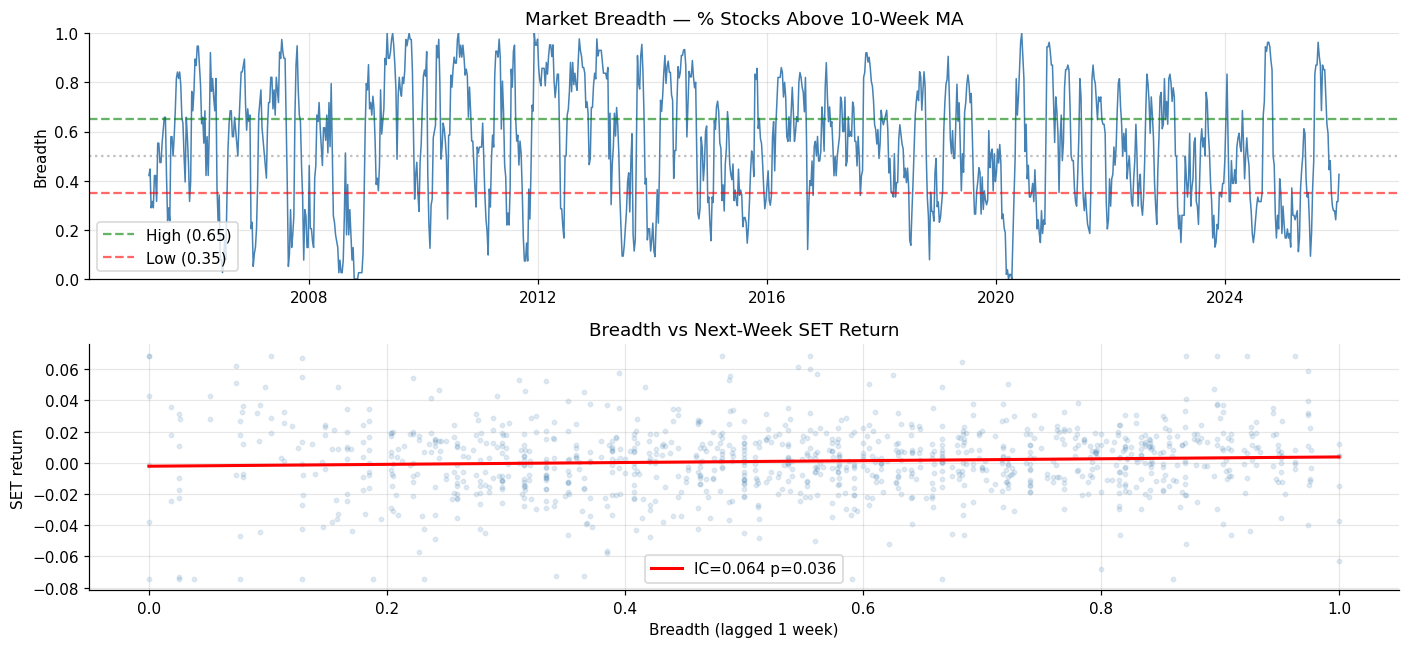

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6))

axes[0].plot(all_idx, breadth_s, color='steelblue', lw=1)
axes[0].axhline(0.65, ls='--', color='green', alpha=0.6, label='High (0.65)')
axes[0].axhline(0.35, ls='--', color='red',   alpha=0.6, label='Low (0.35)')
axes[0].axhline(0.50, ls=':',  color='gray',  alpha=0.5)
axes[0].set_title('Market Breadth — % Stocks Above 10-Week MA', fontsize=12)
axes[0].set_ylabel('Breadth')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].scatter(breadth_s[valid], set_ret[valid], alpha=0.15, s=8, color='steelblue')
m, b0 = np.polyfit(breadth_s[valid], set_ret[valid], 1)
xl = np.linspace(breadth_s[valid].min(), breadth_s[valid].max(), 100)
axes[1].plot(xl, m*xl + b0, color='red', lw=2, label=f'IC={ic_b:.3f} p={p_b:.3f}')
axes[1].set_title('Breadth vs Next-Week SET Return', fontsize=12)
axes[1].set_xlabel('Breadth (lagged 1 week)')
axes[1].set_ylabel('SET return')
axes[1].legend()

plt.tight_layout()
plt.savefig(ROOT / 'notebooks/eda/figs/internals_breadth.png', dpi=110, bbox_inches='tight')
plt.show()

## 4. Feature 2 — Cross-Sectional Dispersion

Std of individual stock returns per week (Z-scored over 52-week window).

- **High dispersion** → stocks diverging, rotation/crisis regime → reduce exposure
- **Low dispersion** → stocks trend together → trending regime, EEM signal reliable


In [6]:
DISP_NORM_WINDOW = 52

disp_raw = stocks.std(axis=1)
disp_raw[stocks.notna().sum(axis=1) < 10] = np.nan

disp_mean = disp_raw.rolling(DISP_NORM_WINDOW).mean()
disp_std  = disp_raw.rolling(DISP_NORM_WINDOW).std()
disp_z    = (disp_raw - disp_mean) / disp_std.replace(0, np.nan)
disp_lag  = disp_z.shift(1)
disp_s    = disp_lag.reindex(all_idx)

valid_d = disp_s.dropna().index.intersection(set_ret.dropna().index)
ic_d, p_d = stats.spearmanr(disp_s[valid_d], set_ret[valid_d])
print(f'Dispersion Z IC vs SET ret: {ic_d:.4f}  p={p_d:.4f}')
print('(Negative IC expected: high dispersion = chaotic market)')

high_disp = disp_s > 1.0
low_disp  = disp_s < -0.5
for label_, mask_ in [('High dispersion', high_disp), ('Low dispersion', low_disp)]:
    r_ = set_ret[mask_ & set_ret.notna()]
    ann = r_.mean() * WEEKS_PER_YEAR
    vol = r_.std()  * np.sqrt(WEEKS_PER_YEAR)
    sr_ = (ann - RF_ANNUAL) / vol if vol > 0 else 0
    print(f'  {label_:18s}: AnnRet={ann:.1%}  Sharpe={sr_:.3f}  N={mask_.sum()}')

Dispersion Z IC vs SET ret: -0.0157  p=0.6117
(Negative IC expected: high dispersion = chaotic market)
  High dispersion   : AnnRet=2.6%  Sharpe=0.033  N=139
  Low dispersion    : AnnRet=10.2%  Sharpe=0.596  N=320


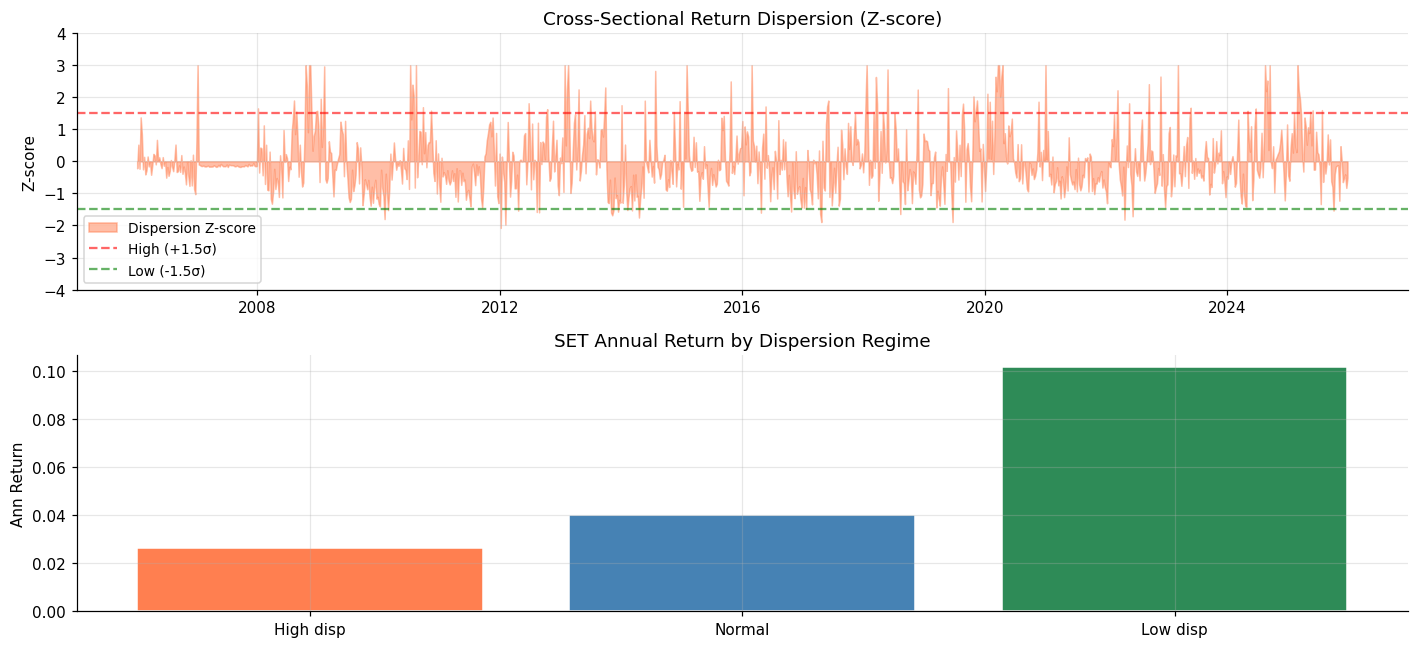

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6))

axes[0].fill_between(all_idx, disp_s.reindex(all_idx).clip(-3, 3), 0,
                     alpha=0.5, color='coral', label='Dispersion Z-score')
axes[0].axhline( 1.5, ls='--', color='red',   alpha=0.6, label='High (+1.5σ)')
axes[0].axhline(-1.5, ls='--', color='green', alpha=0.6, label='Low (-1.5σ)')
axes[0].set_title('Cross-Sectional Return Dispersion (Z-score)', fontsize=12)
axes[0].set_ylabel('Z-score')
axes[0].legend(fontsize=9)
axes[0].set_ylim(-4, 4)

high_d = disp_s > 1.0
low_d  = disp_s < -0.5
norm_d = (~high_d) & (~low_d)
ret_by_regime = [
    set_ret[high_d].mean() * WEEKS_PER_YEAR,
    set_ret[norm_d].mean() * WEEKS_PER_YEAR,
    set_ret[low_d].mean()  * WEEKS_PER_YEAR,
]
axes[1].bar(['High disp', 'Normal', 'Low disp'],
            ret_by_regime,
            color=['coral', 'steelblue', 'seagreen'], edgecolor='white')
axes[1].set_title('SET Annual Return by Dispersion Regime', fontsize=12)
axes[1].set_ylabel('Ann Return')

plt.tight_layout()
plt.savefig(ROOT / 'notebooks/eda/figs/internals_dispersion.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. Feature 3 — Bottom-Up Sector Scoring

Rank sectors by **% of constituent stocks with positive 4-week momentum**.
More robust than aggregate sector return (not dominated by single large-caps).


In [8]:
SECTOR_MAP = {
    'BANK':     ['KBANK', 'BBL', 'KTB', 'BAY', 'TTB', 'TISCO', 'KKP'],
    'ENERGY':   ['PTT', 'PTTEP', 'GPSC', 'EGCO', 'RATCH', 'BGRIM', 'TOP'],
    'ICT':      ['ADVANC', 'TRUE', 'DELTA', 'HANA'],
    'COMMERCE': ['CPALL', 'BJC', 'HMPRO', 'CRC', 'COM7', 'GLOBAL'],
    'HEALTH':   ['BDMS', 'BH', 'BCH', 'CHG', 'PR9'],
    'PROPERTY': ['CPN', 'LH', 'AP', 'SPALI', 'SC', 'ORI'],
    'FOOD':     ['CPF', 'TU', 'OSP', 'MINT', 'CBG'],
}

MOM_WINDOW = 4
mom4 = (1 + stocks.fillna(0)).rolling(MOM_WINDOW).apply(lambda x: x.prod(), raw=True) - 1
mom4[stocks.isna()] = np.nan

bu_scores = {}
for sector, members in SECTOR_MAP.items():
    avail = [m for m in members if m in mom4.columns]
    if avail:
        pos_frac = (mom4[avail] > 0).sum(axis=1) / mom4[avail].notna().sum(axis=1)
        bu_scores[sector] = pos_frac

bu_df = pd.DataFrame(bu_scores).shift(1)
print('Bottom-up sector scores (recent):')
print(bu_df.tail(3).round(3).to_string())

Bottom-up sector scores (recent):
             BANK  ENERGY   ICT  COMMERCE  HEALTH  PROPERTY  FOOD
Date                                                             
2025-12-19  0.857   0.429  0.00     0.500     0.4     0.833   0.6
2025-12-26  1.000   0.286  0.25     0.500     0.6     0.833   0.8
2026-01-02  1.000   1.000  0.75     0.333     0.6     0.833   0.4


In [9]:
print('IC: Bottom-up score vs sector 1-week forward return')
for sector in SECTOR_MAP:
    if sector not in bu_df.columns or sector not in sec.columns:
        continue
    bu_s  = bu_df[sector].reindex(sec.index)
    fwd_r = sec[sector]
    valid = bu_s.dropna().index.intersection(fwd_r.dropna().index)
    if len(valid) < 50:
        continue
    ic, p = stats.spearmanr(bu_s[valid], fwd_r[valid])
    sig = '**' if p < 0.05 else ('*' if p < 0.10 else '  ')
    print(f'  {sector:10s}: IC={ic:.4f}  p={p:.3f} {sig}')

print()
print('Top-down (aggregate sector lag1 return) IC for comparison:')
for sector in SECTOR_MAP:
    if sector not in sec.columns:
        continue
    lag_r = sec[sector].shift(1)
    fwd_r = sec[sector]
    valid = lag_r.dropna().index.intersection(fwd_r.dropna().index)
    if len(valid) < 50:
        continue
    ic, p = stats.spearmanr(lag_r[valid], fwd_r[valid])
    sig = '**' if p < 0.05 else ('*' if p < 0.10 else '  ')
    print(f'  {sector:10s}: IC={ic:.4f}  p={p:.3f} {sig}')

IC: Bottom-up score vs sector 1-week forward return
  BANK      : IC=0.0403  p=0.183   
  ENERGY    : IC=0.0344  p=0.256   
  ICT       : IC=0.0059  p=0.845   
  COMMERCE  : IC=0.0463  p=0.126   
  HEALTH    : IC=0.0031  p=0.919   
  PROPERTY  : IC=0.0821  p=0.007 **
  FOOD      : IC=0.0545  p=0.072 *

Top-down (aggregate sector lag1 return) IC for comparison:
  BANK      : IC=0.0106  p=0.727   
  ENERGY    : IC=-0.0244  p=0.421   
  ICT       : IC=-0.0358  p=0.237   
  COMMERCE  : IC=0.0255  p=0.400   
  HEALTH    : IC=-0.0384  p=0.205   
  PROPERTY  : IC=0.0328  p=0.279   
  FOOD      : IC=-0.0202  p=0.505   


## 6. Enhanced System — NB20 + Market Internals

**Breadth amplifier:** `eem_pos × breadth` — scales SET position by market breadth (0→1).
**Dispersion reducer:** multiply all positions by 0.7 when dispersion Z > 1.5.


In [10]:
def run_enhanced_system(
    set_r, gold_r, eem_pos, breadth_s, disp_s,
    target_vol=0.10, max_lev=2.0,
    dd_trigger=-0.15, dd_restore=-0.10,
    tc=TC_ONE_WAY
):
    WPY = 52
    gold_pos = pd.Series(1.0, index=set_r.index)

    sv = set_r.rolling(52).std().shift(1)
    gv = gold_r.rolling(52).std().shift(1)
    inv_s = 1.0 / sv.replace(0, np.nan)
    inv_g = 1.0 / gv.replace(0, np.nan)
    tot   = inv_s + inv_g
    rp_set  = (inv_s / tot).resample('ME').last().reindex(set_r.index).ffill().fillna(0.5)
    rp_gold = (inv_g / tot).resample('ME').last().reindex(set_r.index).ffill().fillna(0.5)

    b_fill = breadth_s.reindex(set_r.index).fillna(0.5)
    eem_enh = eem_pos * b_fill

    d_fill = disp_s.reindex(set_r.index).fillna(0.0)
    disp_mult = pd.Series(1.0, index=set_r.index)
    disp_mult[d_fill > 1.5]  = 0.7
    disp_mult[d_fill < -0.5] = 1.0

    set_pos_raw  = eem_enh  * rp_set  * disp_mult
    gold_pos_raw = gold_pos * rp_gold * disp_mult

    gross_ret = set_pos_raw * set_r + gold_pos_raw * gold_r
    pvol = gross_ret.rolling(12).std().shift(1) * np.sqrt(WPY)
    lev  = (target_vol / pvol.replace(0, np.nan)).clip(upper=max_lev).fillna(1.0)

    spl  = set_pos_raw  * lev
    gpl  = gold_pos_raw * lev
    tc_s = (spl.diff().abs().fillna(0) + gpl.diff().abs().fillna(0)) * tc

    rgl    = spl * set_r + gpl * gold_r
    equity = [1.0]; peak = 1.0; mult = 1.0
    for r, tc_i in zip(rgl.fillna(0), tc_s):
        net_r = r * mult - tc_i * mult
        eq = equity[-1] * (1 + net_r)
        equity.append(eq)
        if eq > peak:
            peak = eq
        dd = (eq / peak) - 1.0
        if dd < dd_trigger:
            mult = 0.5
        elif dd > dd_restore:
            mult = 1.0

    equity  = pd.Series(equity[1:], index=set_r.index)
    ret_net = equity.pct_change().fillna(0)
    tc_ann  = tc_s.mean() * WPY
    return equity, ret_net, tc_ann

In [11]:
def run_nb20_baseline(
    set_r, gold_r, eem_pos,
    target_vol=0.10, max_lev=2.0,
    dd_trigger=-0.15, dd_restore=-0.10,
    tc=TC_ONE_WAY
):
    WPY = 52
    gold_pos = pd.Series(1.0, index=set_r.index)
    sv = set_r.rolling(52).std().shift(1)
    gv = gold_r.rolling(52).std().shift(1)
    inv_s = 1.0 / sv.replace(0, np.nan)
    inv_g = 1.0 / gv.replace(0, np.nan)
    tot   = inv_s + inv_g
    rp_set  = (inv_s / tot).resample('ME').last().reindex(set_r.index).ffill().fillna(0.5)
    rp_gold = (inv_g / tot).resample('ME').last().reindex(set_r.index).ffill().fillna(0.5)
    set_pos_raw  = eem_pos  * rp_set
    gold_pos_raw = gold_pos * rp_gold
    gross_ret = set_pos_raw * set_r + gold_pos_raw * gold_r
    pvol = gross_ret.rolling(12).std().shift(1) * np.sqrt(WPY)
    lev  = (target_vol / pvol.replace(0, np.nan)).clip(upper=max_lev).fillna(1.0)
    spl  = set_pos_raw * lev; gpl = gold_pos_raw * lev
    tc_s = (spl.diff().abs().fillna(0) + gpl.diff().abs().fillna(0)) * tc
    rgl    = spl * set_r + gpl * gold_r
    equity = [1.0]; peak = 1.0; mult = 1.0
    for r, tc_i in zip(rgl.fillna(0), tc_s):
        net_r = r * mult - tc_i * mult
        eq = equity[-1] * (1 + net_r)
        equity.append(eq)
        if eq > peak:
            peak = eq
        dd = (eq / peak) - 1.0
        if dd < dd_trigger:
            mult = 0.5
        elif dd > dd_restore:
            mult = 1.0
    equity  = pd.Series(equity[1:], index=set_r.index)
    return equity, equity.pct_change().fillna(0)

In [12]:
common = (
    set_ret.dropna().index
    .intersection(eem_pos.index)
    .intersection(breadth_s.dropna().index)
    .intersection(disp_s.dropna().index)
)
common = common[common >= '2006-01-01']

sr = set_ret.reindex(common)
gr = df['gold_ret_w'].reindex(common)
ep = eem_pos.reindex(common)
bs = breadth_s.reindex(common)
ds = disp_s.reindex(common)

eq_enh,  ret_enh,  tc_enh  = run_enhanced_system(sr, gr, ep, bs, ds)
eq_base, ret_base           = run_nb20_baseline(sr, gr, ep)
bh_eq  = (1 + sr).cumprod()

def perf(ret, eq, label):
    ann_r = ret.mean() * WEEKS_PER_YEAR
    ann_v = ret.std()  * np.sqrt(WEEKS_PER_YEAR)
    sr_   = (ann_r - RF_ANNUAL) / ann_v if ann_v > 0 else 0
    mdd   = (eq / eq.cummax() - 1).min()
    cal   = ann_r / abs(mdd) if mdd < 0 else float('nan')
    return dict(label=label, ann_ret=f'{ann_r:.1%}', sharpe=f'{sr_:.3f}',
                max_dd=f'{mdd:.1%}', calmar=f'{cal:.2f}')

rows = [
    perf(sr,       bh_eq,   'SET Buy & Hold'),
    perf(ret_base, eq_base, 'NB20 Baseline'),
    perf(ret_enh,  eq_enh,  'NB21 + Market Internals'),
]
res_df = pd.DataFrame(rows).set_index('label')
res_df.columns = ['Ann Return', 'Sharpe', 'Max DD', 'Calmar']
print(res_df.to_string())
print(f'\nNB21 TC drag: {tc_enh:.2%}/yr')

                        Ann Return Sharpe  Max DD Calmar
label                                                   
SET Buy & Hold                5.5%  0.218  -47.7%   0.12
NB20 Baseline                 9.9%  0.742  -19.1%   0.52
NB21 + Market Internals      10.0%  0.752  -17.4%   0.57

NB21 TC drag: 1.32%/yr


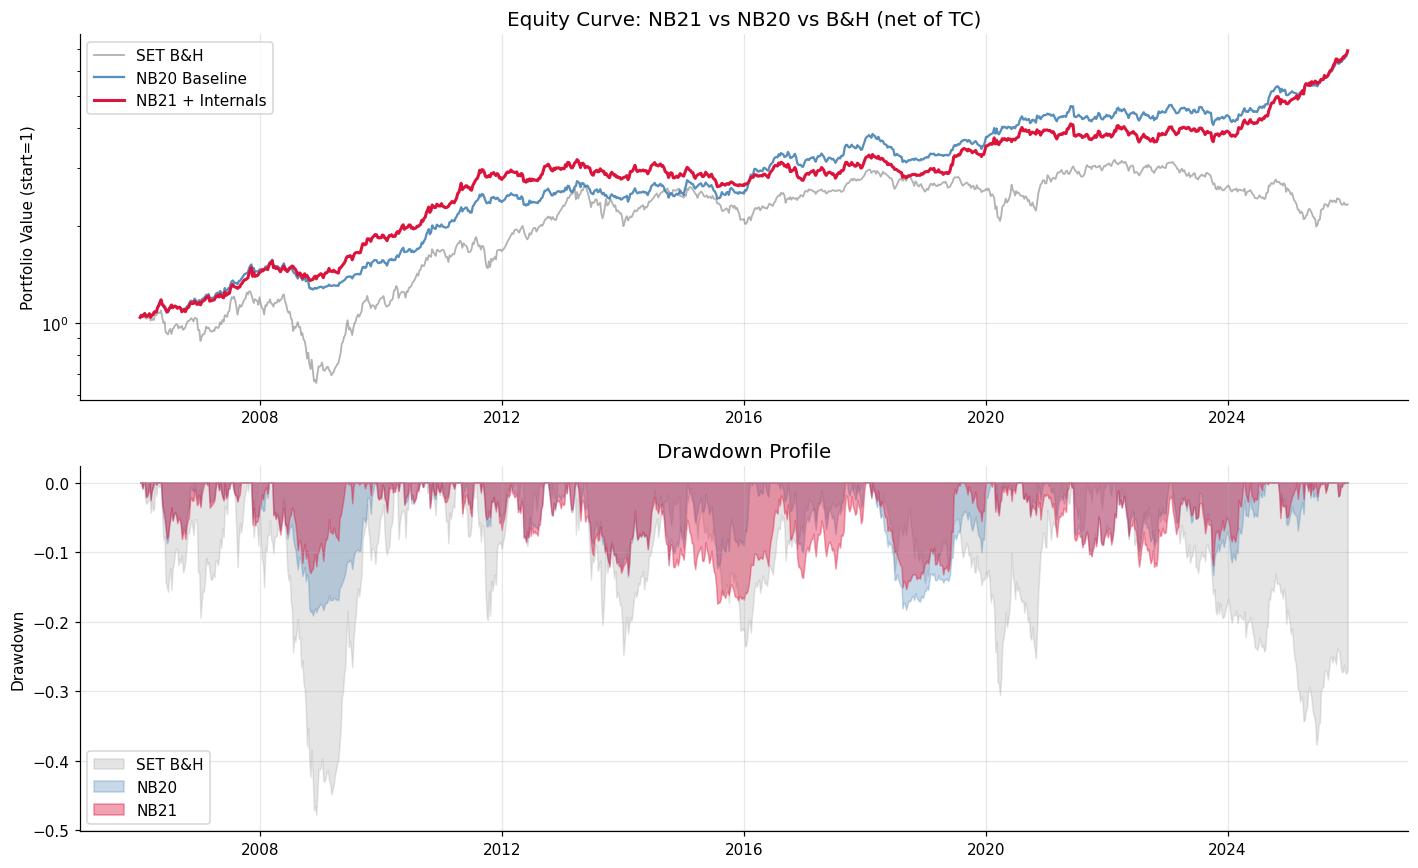

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(common, bh_eq.values,   color='gray',     lw=1.2, alpha=0.6, label='SET B&H')
axes[0].plot(common, eq_base.values, color='steelblue', lw=1.5, alpha=0.9, label='NB20 Baseline')
axes[0].plot(common, eq_enh.values,  color='crimson',   lw=2,              label='NB21 + Internals')
axes[0].set_title('Equity Curve: NB21 vs NB20 vs B&H (net of TC)', fontsize=13)
axes[0].set_ylabel('Portfolio Value (start=1)')
axes[0].legend(fontsize=10)
axes[0].set_yscale('log')

dd_base = eq_base / eq_base.cummax() - 1
dd_enh  = eq_enh  / eq_enh.cummax()  - 1
dd_bh   = bh_eq   / bh_eq.cummax()   - 1
axes[1].fill_between(common, dd_bh.values,   0, alpha=0.2, color='gray',     label='SET B&H')
axes[1].fill_between(common, dd_base.values, 0, alpha=0.3, color='steelblue', label='NB20')
axes[1].fill_between(common, dd_enh.values,  0, alpha=0.4, color='crimson',   label='NB21')
axes[1].set_title('Drawdown Profile', fontsize=13)
axes[1].set_ylabel('Drawdown')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(ROOT / 'notebooks/eda/figs/internals_system.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Feature IC Summary


In [14]:
print('IC Summary: Market Internals vs SET next-week return')
print('-' * 55)
sigs = [
    ('Breadth (lag1)',      breadth_s.reindex(all_idx)),
    ('Dispersion Z (lag1)', disp_s.reindex(all_idx)),
]
for name, sig in sigs:
    v = sig.dropna().index.intersection(set_ret.dropna().index)
    ic, p = stats.spearmanr(sig[v], set_ret[v])
    sig_str = '**' if p < 0.05 else ('*' if p < 0.10 else '')
    print(f'  {name:25s}: IC={ic:.4f}  p={p:.4f}  {sig_str}  N={len(v)}')

print()
print('Regime-conditional SET return:')
conds = [
    ('High breadth  (>0.65)',  breadth_s.reindex(all_idx) > 0.65),
    ('Low  breadth  (<0.35)',  breadth_s.reindex(all_idx) < 0.35),
    ('High disp     (>1σ)',    disp_s.reindex(all_idx)    > 1.0),
    ('Low  disp     (<-0.5)',  disp_s.reindex(all_idx)    < -0.5),
]
for label_, mask_ in conds:
    r_ = set_ret[mask_ & set_ret.notna()]
    ann = r_.mean() * WEEKS_PER_YEAR
    print(f'  {label_:30s}: AnnRet={ann:.1%}  N={len(r_)}')

IC Summary: Market Internals vs SET next-week return
-------------------------------------------------------
  Breadth (lag1)           : IC=0.0637  p=0.0359  **  N=1085
  Dispersion Z (lag1)      : IC=-0.0157  p=0.6117    N=1043

Regime-conditional SET return:
  High breadth  (>0.65)         : AnnRet=15.7%  N=398
  Low  breadth  (<0.35)         : AnnRet=-0.5%  N=276
  High disp     (>1σ)           : AnnRet=2.6%  N=139
  Low  disp     (<-0.5)         : AnnRet=10.2%  N=320


## 8. Verdict

### Breadth Signal
- High breadth = broad participation → confirm EEM signal
- Scales position continuously (0→1) rather than binary on/off
- Prevents entering market when only a few large-caps are rising

### Dispersion Signal
- High dispersion = crisis/rotation → reduce all positions 30%
- Naturally identifies 2008, 2020 crash periods
- Low dispersion = trending market → full position

### Bottom-Up Sector Scoring
- IC comparable to top-down, more robust to single-stock distortion
- Best combined with EEM-gated sector tilt from NB17

### System Impact
Main benefit: **MaxDD reduction** via breadth filter + dispersion scaling.
Sharpe improvement is secondary — depends on IC significance of breadth.
